In [1]:

import warnings
from pathlib import Path

import xarray as xr
from matplotlib import pyplot as plt

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace,
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.population import compute_population, compute_total_population, compute_rur_urb_pop
from imagematerials.util import merge_dims, dataset_to_array


In [2]:
base_directory = Path("..", "data", "raw")

database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

In [3]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)


In [4]:


# Rural/Urban floorspace [Time, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})

# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})



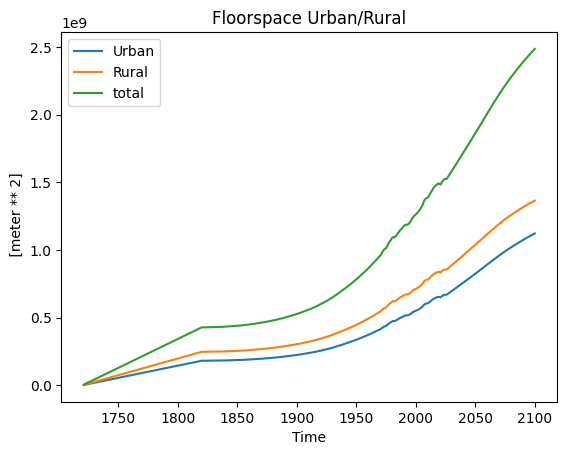

In [5]:
# Rural/Urban floorspace [Year, Region, Area]

floorspace_rururb.sum("Region").sel(Area="Urban").plot(label="Urban")
floorspace_rururb.sum("Region").sel(Area="Rural").plot(label="Rural")
floorspace_rururb.sum(["Region", "Area"]).plot(label="total")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [6]:
# Calculate population ("Total", "Rural", "Urban")
urban_pop_total, rural_pop_total = compute_rur_urb_pop(image_directory, base_directory)
population = compute_population(image_directory, base_directory)

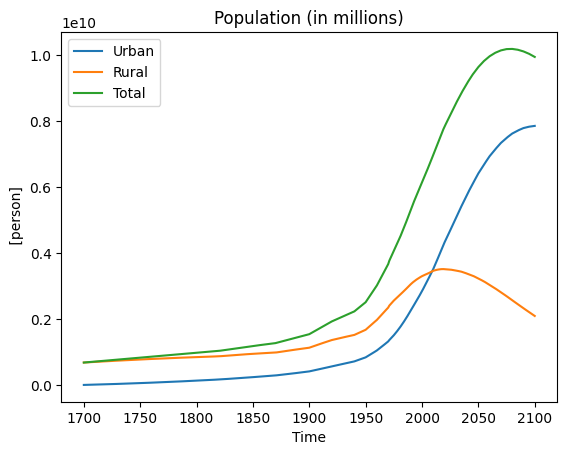

In [7]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [8]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)
housing_type = compute_housing_type(database_directory)

# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, average_m2_capita, housing_type, floorspace_rururb, None)

meter ** 2 / person m2_housing_per_capita
dimensionless m2_housing_share
meter ** 2 total_m2_housing_per_cap


c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials\Lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [9]:
housing_type

Magnitude,[[[[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.024155 0.956522 0.004831 0.014493] [0.089533 0.664565 0.174023 0.071879]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] ... [[0.04375 0.90625 0.0 0.05] [0.19025 0.260404 0.070155 0.479191]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]]] [[[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.024155 0.956522 0.004831 0.014493] [0.089533 0.664565 0.174023 0.071879]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] ... [[0.04375 0.90625 0.0 0.05] [0.19025 0.260404 0.070155 0.479191]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]]] [[[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.024155 0.956522 0.004831 0.014493] [0.089533 0.664565 0.174023 0.071879]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] ... [[0.04375 0.90625 0.0 0.05] [0.19025 0.260404 0.070155 0.479191]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]]] ... [[[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.024155 0.956522 0.004831 0.014493] [0.089533 0.664565 0.174023 0.071879]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] ... [[0.04375 0.90625 0.0 0.05] [0.19025 0.260404 0.070155 0.479191]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]]] [[[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.024155 0.956522 0.004831 0.014493] [0.089533 0.664565 0.174023 0.071879]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] ... [[0.04375 0.90625 0.0 0.05] [0.19025 0.260404 0.070155 0.479191]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]]] [[[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.024155 0.956522 0.004831 0.014493] [0.089533 0.664565 0.174023 0.071879]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] ... [[0.04375 0.90625 0.0 0.05] [0.19025 0.260404 0.070155 0.479191]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]] [[0.074349 0.814126 0.037175 0.074349] [0.172131 0.401639 0.22541 0.20082]]]]
Units,dimensionless


In [10]:
m2_housing_per_capita = average_m2_capita * housing_type
m2_housing_share = m2_housing_per_capita / m2_housing_per_capita.sum(["Type"])
total_m2_housing_per_cap = m2_housing_share*floorspace_rururb

total_m2_housing = total_m2_housing_per_cap * population.sel({"Area": ["Rural", "Urban"]}).loc[1721:2060]

In [11]:
population.sel({"Area": ["Rural", "Urban"]}).loc[1721:2060]

Magnitude,[[[4052343.413008896 252332.3822954521] [37628051.49160487 2276260.9569317894] [9733602.798133595 472706.75921260595] ... [3199658.041332561 212108.4690383771] [32284174.769371413 388554.20886856917] [9018182.152636133 86077.71137759555]] [[4056436.0459058885 265402.1450433491] [37669245.96730871 2394161.7605811814] [9749810.297808608 497190.9936023172] ... [3202274.1474221065 223094.80120047482] [32394312.823940255 408679.6928766538] [9050021.637669329 90536.1770543071]] [[4060432.8665283755 278567.72006574995] [37709576.13167183 2512926.87557129] [9765838.30760063 521854.7178750209] ... [3204809.714523055 234161.6723511684] [32504303.341906052 428952.7134877739] [9081828.438426185 95027.32700735348]] ... [[3450229.999999997 39758380.0] [28836999.99999999 357122700.0] [15607100.000000006 136527000.0] ... [3303549.999999992 39548340.0] [336233300.0 418969300.0] [166984599.99999997 237476200.00000003]] [[3390720.0000000023 39925270.0] [28332400.000000015 358643300.0] [15373000.000000017 136966300.0] ... [3260100.0000000033 39773590.0] [334987799.99999994 425267200.00000006] [167452399.99999997 242141400.0]] [[3330880.0 40092500.0] [27824900.000000026 360166900.0] [15138299.999999981 137406200.0] ... [3216180.0000000014 39999320.0] [333695800.00000006 431611599.99999994] [167878700.00000003 246848100.0]]]
Units,person


In [12]:
total_m2_housing_per_cap

<xarray.DataArray (Region: 26, Area: 2, Type: 4, Time: 380)> Size: 632kB
<Quantity([[[[4.79012025e+03 9.58024050e+03 1.43703608e+04 ... 3.44262529e+06
    3.43302385e+06 3.42301162e+06]
   [7.86781552e+04 1.57356310e+05 2.36034466e+05 ... 5.65454295e+07
    5.63877249e+07 5.62232732e+07]
   [3.41844997e+03 6.83689995e+03 1.02553499e+04 ... 2.45681564e+06
    2.44996361e+06 2.44281842e+06]
   [7.10026461e+03 1.42005292e+04 2.13007938e+04 ... 5.10290958e+06
    5.08867762e+06 5.07383677e+06]]

  [[9.27267443e+03 1.85453489e+04 2.78180233e+04 ... 8.12681328e+06
    8.12857240e+06 8.13033286e+06]
   [2.92062776e+04 5.84125551e+04 8.76188327e+04 ... 2.55971421e+07
    2.56026828e+07 2.56082277e+07]
   [1.49397698e+04 2.98795395e+04 4.48193093e+04 ... 1.30936032e+07
    1.30964374e+07 1.30992738e+07]
   [1.53707682e+04 3.07415365e+04 4.61123047e+04 ... 1.34713415e+07
    1.34742575e+07 1.34771757e+07]]]


 [[[1.52641144e+03 3.05282287e+03 4.57923431e+03 ... 1.15885769e+06
...
    6.61589645e+06 6.65254304e+06]]]


 [[[4.79012025e+03 9.58024050e+03 1.43703608e+04 ... 2.35525254e+06
    2.38941694e+06 2.42242646e+06]
   [7.86781552e+04 1.57356310e+05 2.36034466e+05 ... 3.86852344e+07
    3.92463877e+07 3.97885720e+07]
   [3.41844997e+03 6.83689995e+03 1.02553499e+04 ... 1.68081646e+06
    1.70519775e+06 1.72875486e+06]
   [7.10026461e+03 1.42005292e+04 2.13007938e+04 ... 3.49112660e+06
    3.54176756e+06 3.59069667e+06]]

  [[9.97360565e+03 1.99472113e+04 2.99208169e+04 ... 5.20006544e+06
    5.27741764e+06 5.35228765e+06]
   [2.79488714e+04 5.58977428e+04 8.38466141e+04 ... 1.45720580e+07
    1.47888208e+07 1.49986278e+07]
   [1.43343522e+04 2.86687043e+04 4.30030565e+04 ... 7.47368323e+06
    7.58485603e+06 7.69246136e+06]
   [1.65326608e+04 3.30653216e+04 4.95979824e+04 ... 8.61984332e+06
    8.74806552e+06 8.87217316e+06]]]], 'meter ** 2')>
Coordinates:
  * Area     (Area) object 16B 'Rural' 'Urban'
  * Type     (Type) <U13 208B 'Appartment' 'Detached' ... 'Semi-detached'
  * Region   (Region) <U2 208B '1' '2' '3' '4' '5' ... '22' '23' '24' '25' '26'
  * Time     (Time) int64 3kB 1721 1722 1723 1724 1725 ... 2097 2098 2099 2100

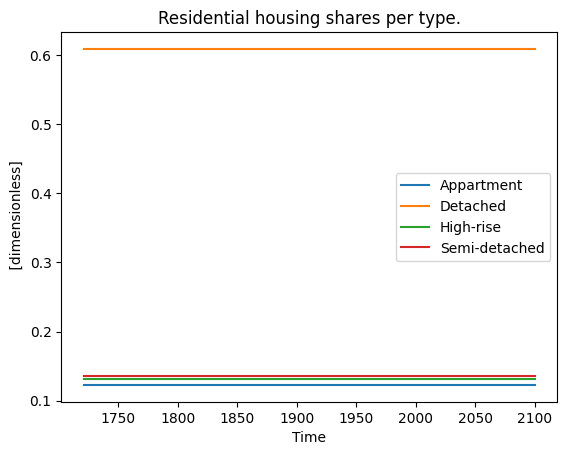

In [13]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

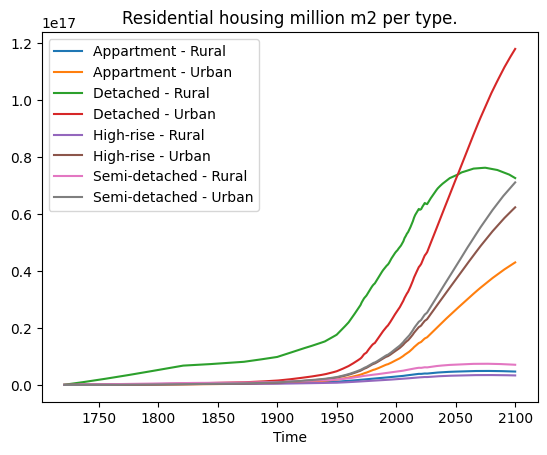

In [14]:


for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [15]:

floorspace = xr.concat((floorspace_residential, floorspace_commercial), dim="Type")

DimensionalityError: Cannot convert from 'dimensionless' to 'meter ** 2'